# House Sales Price Prediction in King Count area, USA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
%matplotlib inline

In [3]:
#importing

filepath=r"C:\Users\Pavni Rastogi\Desktop\data sci practice projects\house-sale-price-prediction\kc_house_data_NaN.csv"
df = pd.read_csv(filepath, header=None)

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1,7129300520,20141013T000000,221900,3,1,1180,5650,1,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
2,6414100192,20141209T000000,538000,3,2.25,2570,7242,2,0,0,...,7,2170,400,1951,1991,98125,47.721,-122.319,1690,7639
3,5631500400,20150225T000000,180000,2,1,770,10000,1,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
4,2487200875,20141209T000000,604000,4,3,1960,5000,1,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000


## Data Wrangling

In [5]:
df.columns = df.iloc[0]   # Set first row as column headers
df = df[1:]               # Remove the first row
df.drop(columns=['id', 'date'], inplace=True)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1,221900,3,1,1180,5650,1,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
2,538000,3,2.25,2570,7242,2,0,0,3,7,2170,400,1951,1991,98125,47.721,-122.319,1690,7639
3,180000,2,1,770,10000,1,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
4,604000,4,3,1960,5000,1,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
5,510000,3,2,1680,8080,1,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
df.dtypes

0
price            object
bedrooms         object
bathrooms        object
sqft_living      object
sqft_lot         object
floors           object
waterfront       object
view             object
condition        object
grade            object
sqft_above       object
sqft_basement    object
yr_built         object
yr_renovated     object
zipcode          object
lat              object
long             object
sqft_living15    object
sqft_lot15       object
dtype: object

In [7]:
numeric_cols = ['price','bedrooms','bathrooms','sqft_living',
    'sqft_lot','floors','waterfront','view','condition',
    'grade','sqft_above','sqft_basement','yr_built',
    'yr_renovated','zipcode','lat','long',
    'sqft_living15','sqft_lot15'
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)
df.dtypes


0
price              int64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [8]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1,221900,3.0,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
2,538000,3.0,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
3,180000,2.0,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
4,604000,4.0,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
5,510000,3.0,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [9]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [10]:
for column_name in df.columns:
    print(f"number of NaN values for the column {column_name}", df[column_name].isnull().sum())


number of NaN values for the column price 0
number of NaN values for the column bedrooms 13
number of NaN values for the column bathrooms 10
number of NaN values for the column sqft_living 0
number of NaN values for the column sqft_lot 0
number of NaN values for the column floors 0
number of NaN values for the column waterfront 0
number of NaN values for the column view 0
number of NaN values for the column condition 0
number of NaN values for the column grade 0
number of NaN values for the column sqft_above 0
number of NaN values for the column sqft_basement 0
number of NaN values for the column yr_built 0
number of NaN values for the column yr_renovated 0
number of NaN values for the column zipcode 0
number of NaN values for the column lat 0
number of NaN values for the column long 0
number of NaN values for the column sqft_living15 0
number of NaN values for the column sqft_lot15 0


In [11]:
#replacing missing values in bedrooms and bathrooms columns with mean:
mean_bedrooms = df['bedrooms'].mean()
df['bedrooms'] = df['bedrooms'].fillna(mean_bedrooms)

# Replacing missing values for bathrooms
mean_bathrooms = df['bathrooms'].mean()
df['bathrooms'] = df['bathrooms'].fillna(mean_bathrooms)

print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 0


## Exploratory Data Analysis

In [12]:
df['floors'].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


CORRELATION:

In [13]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr()['price'].sort_values()

0
zipcode         -0.053203
long             0.021626
condition        0.036362
yr_built         0.054012
sqft_lot15       0.082447
sqft_lot         0.089661
yr_renovated     0.126434
floors           0.256794
waterfront       0.266369
lat              0.307003
bedrooms         0.308797
sqft_basement    0.323816
view             0.397293
bathrooms        0.525738
sqft_living15    0.585379
sqft_above       0.605567
grade            0.667434
sqft_living      0.702035
price            1.000000
Name: price, dtype: float64

<Axes: xlabel='sqft_above', ylabel='price'>

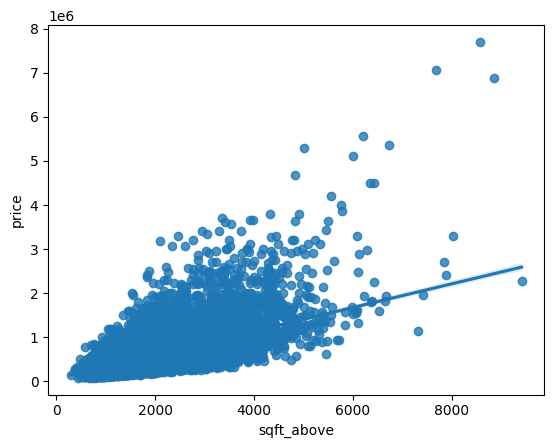

In [14]:
sns.regplot(x='sqft_above', y='price', data=df)

<Axes: xlabel='waterfront', ylabel='price'>

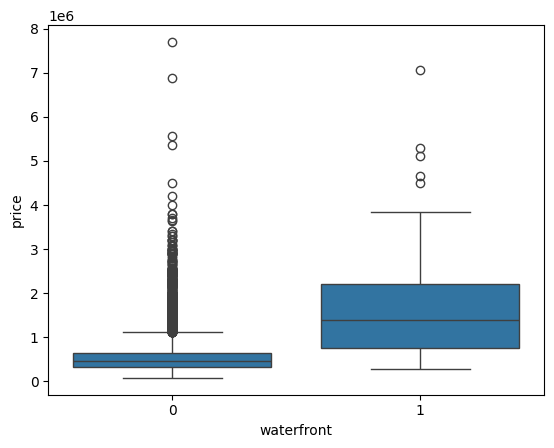

In [15]:
sns.boxplot(x='waterfront', y='price', data=df)

*useful columns:*
yr_renovated (not very useful), floors, waterfront,lat, bedrooms,sqft_basement,view,bathrooms,sqft_living15, sqft_above,grade, (highest corr) sqft_living   

## Model Development (initial)

simple linear regression

In [17]:
lm=LinearRegression()
x=df[['sqft_living']]
y=df[['price']]
lm.fit(x,y)
print(lm.score(x,y))

0.4928532179037931


multivariable linear regression

In [18]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"] 
Z= df[features]
lm.fit(Z, y)
print(lm.score(Z,y))

0.65769516660375


training pipeline using standard scaling, polynomial features and linear regression

In [19]:
Input=[('scale',StandardScaler()),('polynomial', PolynomialFeatures(include_bias=False)),('model',LinearRegression())]
pipe= Pipeline(Input)
pipe.fit(Z,y)
print(pipe.score(Z,y))

0.7513408515988733


## Model Evaluation and Refinement

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

splitting data into training and testing sets:

In [24]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]    
X = df[features]
Y = df[['price']]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)


print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 3242
number of training samples: 18371


Ridge regression mode using the training data, using the regularization parameter to 0.1

In [25]:
ridge_model= Ridge(alpha=0.1)
ridge_model.fit(x_train, y_train)
yhat= ridge_model.predict(x_test)
print(r2_score(y_test, yhat))

0.6478759163939112


second order polynomial transform on both the training data and testing data and then fitting in ridge model again

In [28]:
pf= PolynomialFeatures(degree=2)
x_train_pf= pf.fit_transform(x_train)
x_test_pf= pf.transform(x_test)
ridge_model.fit(x_train_pf, y_train)
y_hat= ridge_model.predict(x_test_pf)
print(r2_score(y_test, y_hat))

0.7002744285363752


*note: using fit transform instead of transform on test input set causes data leakage*